In [7]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\shap_explainability.csv")

In [11]:
#Create LTV Target Variable
df["LTV"] = df["MonthlyCharges"] * df["tenure"]
df["LTV"].describe()

count    7043.000000
mean        0.233390
std         0.264093
min         0.000000
25%         0.014677
50%         0.113806
75%         0.397412
max         1.000000
Name: LTV, dtype: float64

<Axes: >

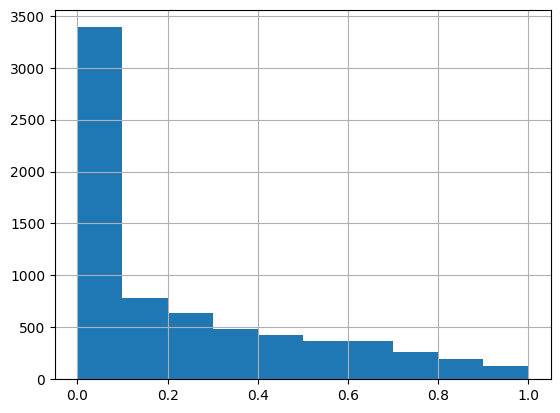

In [12]:
#Verify New Target
df[["MonthlyCharges","tenure","LTV"]].head()
df["LTV"].hist()

In [13]:
#Separate Active Customers
active_customers = df[df["Churn"] == 0]   #dont run 
active_customers.shape

(5174, 47)

In [7]:
#Save Active Customer Dataset
active_customers.to_csv(
    "../../data/processed/active_customers_ltv_day16.csv",
    index=False
)

In [14]:
#Create Regression Dataset
ltv_df = df.copy()
ltv_df.shape

(7043, 47)

In [15]:
#Define Features and Target
X = ltv_df.drop("LTV", axis=1)

y = ltv_df["LTV"]

In [16]:
#verify shape
X.shape
y.shape

(7043,)

In [17]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
X_train.shape

(5634, 46)

In [19]:
X_test.shape

(1409, 46)

In [20]:
y_train.shape

(5634,)

In [21]:
y_test.shape

(1409,)

In [16]:
#Save LTV Dataset
ltv_df.to_csv(
    "../../data/processed/ltv_dataset_day16.csv",
    index=False
)

In [27]:
#Quick Data Quality Check
#ltv_df.isnull().sum()
ltv_df.duplicated().sum()
#ltv_df = ltv_df.drop_duplicates()


np.int64(0)

                                            DAY 17 -> LTV PREPARATION

In [28]:
import pandas as pd

ltv_df = pd.read_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\ltv_dataset_day16.csv")

In [29]:
#Create Features and Target
X = ltv_df.drop("LTV", axis=1)

y = ltv_df["LTV"]

In [30]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
#Import Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np



In [32]:
#MODEL 1 -> LINEAR REGERSSION
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [33]:
#Evaluate Linear Regression
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 :", lr_r2)

MAE : 0.0071548146780665445
MSE : 0.00011199502543093896
RMSE : 0.010582770215351884
R2 : 0.9984153389369913


In [62]:
import joblib

joblib.dump(
    {"MAE": lr_mae, "MSE": lr_mse, "RMSE": lr_rmse, "R2": lr_r2},
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\models\trained models\linear_regression_ltv_day17.pkl"
)

['C:\\Users\\user\\OneDrive\\Desktop\\ZAALIMA PROJECT\\CUSTOMER CHURN PREDICTION LTV ENGINE\\models\\trained models\\linear_regression_ltv_day17.pkl']

In [70]:
#MODEL 2-> RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [71]:
#Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

MAE : 0.004656802681255031
MSE : 6.0063675056124136e-05
RMSE : 0.0077500758097017435
R2 : 0.9991501357600804


In [75]:

import joblib

joblib.dump(
    {
        "MAE": rf_mae,
        "MSE": rf_mse,
        "RMSE": rf_rmse,
        "R2": rf_r2
    },
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\models\trained models\random_forest_ltv_metrics_day17.pkl"
)

['C:\\Users\\user\\OneDrive\\Desktop\\ZAALIMA PROJECT\\CUSTOMER CHURN PREDICTION LTV ENGINE\\models\\trained models\\random_forest_ltv_metrics_day17.pkl']

In [68]:
#MODEL 3 XGBOOST
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [69]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_pred)
print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

MAE : 0.004691963146483951
MSE : 5.785059659412301e-05
RMSE : 0.0076059579668916796
R2 : 0.9991814494657973


In [59]:
import joblib
joblib.dump(
    xgb,
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\models\trained models\xgboost_ltv_day17.pkl"
)

['C:\\Users\\user\\OneDrive\\Desktop\\ZAALIMA PROJECT\\CUSTOMER CHURN PREDICTION LTV ENGINE\\models\\trained models\\xgboost_ltv_day17.pkl']

In [38]:
import pandas as pd
dir()

['In',
 'LinearRegression',
 'Out',
 'RandomForestRegressor',
 'X',
 'XGBRegressor',
 'X_test',
 'X_train',
 '_',
 '_11',
 '_12',
 '_13',
 '_14',
 '_16',
 '_18',
 '_19',
 '_20',
 '_21',
 '_22',
 '_23',
 '_24',
 '_25',
 '_27',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'active_customers',
 'df',
 'exit',
 'get_ipython',
 'lr',
 'lr_mae',
 'lr_mse',
 'lr_pred',
 'lr_r2',
 'lr_rmse',
 'ltv_df',
 'mean_absolute_error',
 'mean_squared_error',
 'np',
 'open',
 'pd',
 'quit',
 'r2_score',
 'rf',
 'rf_mae',
 'rf_mse'

In [39]:
import pandas as pd

df = pd.read_csv("../../data/processed/ltv_dataset_day16.csv")


In [10]:
type(df)

pandas.DataFrame

In [40]:
df.to_csv("../../data/processed/final_ltv_predictions_day17.csv", index=False)

In [41]:
lr_mae, lr_mse, lr_rmse, lr_r2
rf_mae, rf_mse, rf_rmse, rf_r2
xgb_mae, xgb_mse, xgb_rmse, xgb_r2

(0.004691963146483951,
 5.785059659412301e-05,
 np.float64(0.0076059579668916796),
 0.9991814494657973)

In [43]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "MSE": [lr_mse, rf_mse, xgb_mse],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2": [lr_r2, rf_r2, xgb_r2]
})

In [44]:
comparison_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.007155,0.000112,0.010583,0.998415
1,Random Forest,0.004657,0.000060,0.007750,0.999150
2,XGBoost,0.004692,0.000058,0.007606,0.999181


In [45]:
comparison_df.to_csv(
    "../../models/metrics/ltv_model_comparison_day18.csv",
    index=False
)

                                    DAY 18-> LTV Modeling Phase final part

In [42]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\final_ltv_predictions_day17.csv"
)

In [47]:
#Load Model Comparison Results
comparison_df.to_csv(
    "../../models/metrics/ltv_model_comparison_day18.csv",
    index=False
)
comparison_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.007155,0.000112,0.010583,0.998415
1,Random Forest,0.004657,0.000060,0.007750,0.999150
2,XGBoost,0.004692,0.000058,0.007606,0.999181


In [48]:
#Identify Best Model
comparison_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
2,XGBoost,0.004692,0.000058,0.007606,0.999181
1,Random Forest,0.004657,0.000060,0.007750,0.999150
0,Linear Regression,0.007155,0.000112,0.010583,0.998415


In [78]:
import joblib

xgb = joblib.load("../../models/trained models/xgboost_ltv_day17.pkl")

In [80]:
#Verify Model Loaded
type(xgb)

xgboost.sklearn.XGBRegressor

In [81]:
#View Dataset
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgRevenuePerMonth,ServiceCount,EngagementScore,RevenueEfficiency,ContractSecurityScore,...,MonthlyChargeGroup_Low,MonthlyChargeGroup_Medium,MonthlyChargeGroup_Premium,RevenueSegment_LowValue,RevenueSegment_MediumValue,RevenueSegment_VIP,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium,MonthlyChargeCategory_Premium,LTV
0,0,0.013889,0.115423,0.001275,0,0.001258,1,0.013889,0.000638,1,...,True,False,False,True,False,False,True,False,False,0.001603
1,0,0.472222,0.385075,0.215867,0,0.146626,3,1.416667,0.053967,2,...,False,True,False,False,False,False,False,True,False,0.181841
2,0,0.027778,0.354229,0.010310,1,0.010032,3,0.083333,0.002578,1,...,False,True,False,True,False,False,False,True,False,0.009840
3,0,0.625000,0.239303,0.210241,0,0.129379,3,1.875000,0.052560,2,...,False,True,False,False,False,False,False,True,False,0.149565
4,0,0.027778,0.521891,0.015330,1,0.014916,1,0.027778,0.007665,1,...,False,False,False,True,False,False,False,False,False,0.014497


In [82]:
#Check Columns
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'AvgRevenuePerMonth', 'ServiceCount', 'EngagementScore',
       'RevenueEfficiency', 'ContractSecurityScore', 'TotalServices',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       '

In [83]:
#Remove Existing Prediction Columns
columns_to_drop = [
    "Predicted_LTV",
    "LTV_Segment"
]

df = df.drop(
    columns=[col for col in columns_to_drop if col in df.columns],
    errors="ignore"
)

In [84]:
#Remove Target Column If Present
if "LTV" in df.columns:
    df = df.drop("LTV", axis=1)

In [85]:
#Generate LTV Predictions
predicted_ltv = xgb.predict(df)

In [86]:
#Add Predictions
df["Predicted_LTV"] = predicted_ltv

In [87]:
#Create Customer Segments
df["LTV_Segment"] = pd.qcut(
    df["Predicted_LTV"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

In [88]:
#Verify Segment Counts
df["LTV_Segment"].value_counts()

LTV_Segment
Low Value       2348
High Value      2348
Medium Value    2347
Name: count, dtype: int64

In [89]:
#View Top Customers
df.sort_values(
    by="Predicted_LTV",
    ascending=False
).head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgRevenuePerMonth,ServiceCount,EngagementScore,RevenueEfficiency,ContractSecurityScore,...,MonthlyChargeGroup_Medium,MonthlyChargeGroup_Premium,RevenueSegment_LowValue,RevenueSegment_MediumValue,RevenueSegment_VIP,MonthlyChargeCategory_Low,MonthlyChargeCategory_Medium,MonthlyChargeCategory_Premium,Predicted_LTV,LTV_Segment
6118,0,1.0,0.994527,0.984116,0,0.492058,8,8.0,0.109346,3,...,False,True,False,False,True,False,False,True,0.990190,High Value
4610,0,1.0,0.990547,1.000000,1,0.500000,8,8.0,0.111111,2,...,False,True,False,False,True,False,False,True,0.989712,High Value
4155,1,1.0,0.986070,0.971319,0,0.485659,8,8.0,0.107924,3,...,False,True,False,False,True,False,False,True,0.986017,High Value
4586,0,1.0,1.000000,0.998575,0,0.499287,8,8.0,0.110953,3,...,False,True,False,False,True,False,False,True,0.984330,High Value
6768,0,1.0,0.987562,0.998304,0,0.499152,8,8.0,0.110923,3,...,False,True,False,False,True,False,False,True,0.984227,High Value
3205,0,1.0,0.988557,0.956624,0,0.478312,8,8.0,0.106292,3,...,False,True,False,False,True,False,False,True,0.983779,High Value
5347,0,1.0,0.982090,0.989568,0,0.494784,8,8.0,0.109952,3,...,False,True,False,False,True,False,False,True,0.982315,High Value
2368,0,1.0,0.984080,0.982079,0,0.491040,8,8.0,0.109120,3,...,False,True,False,False,True,False,False,True,0.981910,High Value
2025,0,1.0,0.981095,0.976102,0,0.488051,8,8.0,0.108456,3,...,False,True,False,False,True,False,False,True,0.981113,High Value
4206,0,1.0,0.980597,0.973685,0,0.486842,8,8.0,0.108187,3,...,False,True,False,False,True,False,False,True,0.980723,High Value


In [ ]:
#Save Final Prediction DATASET--> TO LOAD FOR DAY 19
df.to_csv(
    "../../data/processed/final_ltv_predictions_day18.csv",
    index=False
)

In [91]:
#Save Customer Segmentation Dataset
df.to_csv(
    "../../data/processed/ltv_customer_segments_day18.csv",
    index=False
)